In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

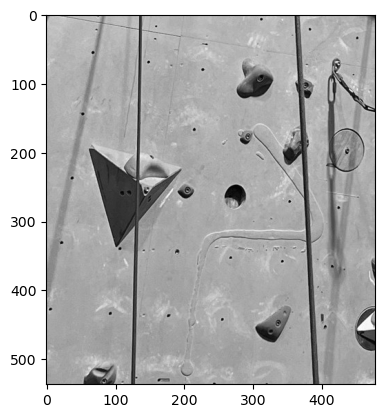

In [3]:
image = cv2.imread('crop.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_image, cmap="gray")
plt.show()

In [90]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(10,10))
clahe_img = clahe.apply(gray_image)
plt.imshow(clahe_img, cmap='gray')
plt.show()

error: OpenCV(4.8.1) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\clahe.cpp:353: error: (-215:Assertion failed) _src.type() == CV_8UC1 || _src.type() == CV_16UC1 in function '`anonymous-namespace'::CLAHE_Impl::apply'


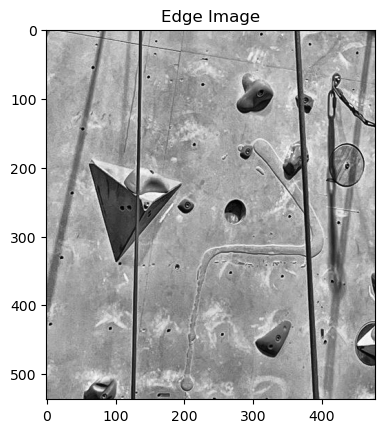

In [83]:
edges = cv2.Canny(gray_image, 100, 200)
plt.imshow(edges, cmap='gray')
plt.title('Edge Image')
plt.show()

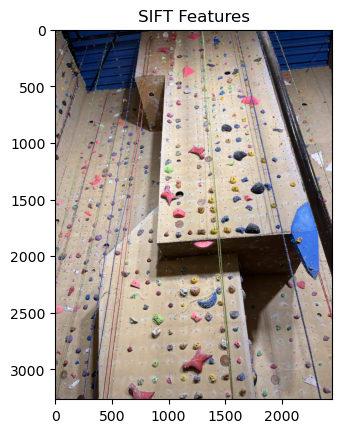

In [7]:
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray_image, None)
image_with_sift = cv2.drawKeypoints(image, keypoints, None)
plt.imshow(cv2.cvtColor(image_with_sift, cv2.COLOR_BGR2RGB))
plt.title('SIFT Features')
plt.show()

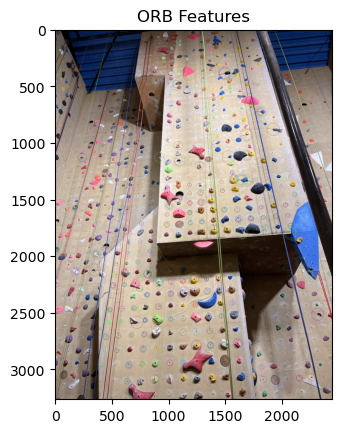

In [8]:
orb = cv2.ORB_create()
keypoints, descriptors = orb.detectAndCompute(gray_image, None)
image_with_orb = cv2.drawKeypoints(image, keypoints, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(cv2.cvtColor(image_with_orb, cv2.COLOR_BGR2RGB))
plt.title('ORB Features')
plt.show()

In [2]:
img2 = cv2.imread('crop.jpg', cv.IMREAD_GRAYSCALE)



NameError: name 'cv' is not defined

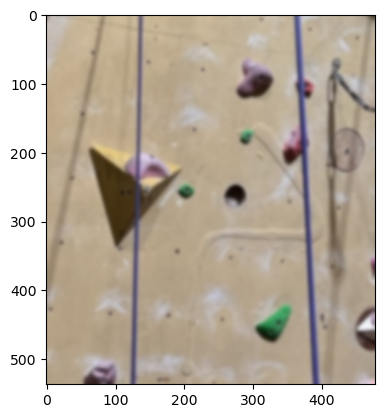

In [10]:
Gaussian = cv2.GaussianBlur(image, (15, 15), 0)  
Gaussian_rgb = cv2.cvtColor(Gaussian, cv2.COLOR_BGR2RGB)  
plt.imshow(Gaussian_rgb)

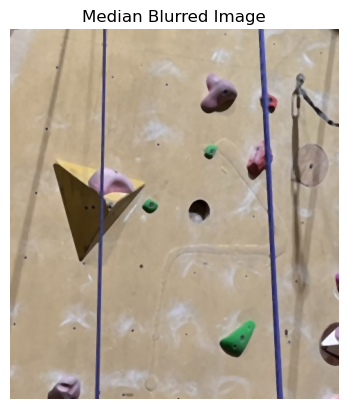

In [36]:
median = cv2.medianBlur(image, 5)  
median_rgb = cv2.cvtColor(median, cv2.COLOR_BGR2RGB)  

plt.imshow(median_rgb)
plt.title('Median Blurred Image')
plt.axis('off')
plt.show()

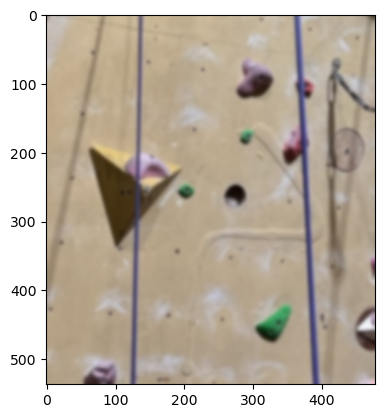

In [45]:
Gaussian = cv2.GaussianBlur(image, (15, 15), 0)  
Gaussian_rgb = cv2.cvtColor(Gaussian, cv2.COLOR_BGR2RGB)  
plt.imshow(Gaussian_rgb)

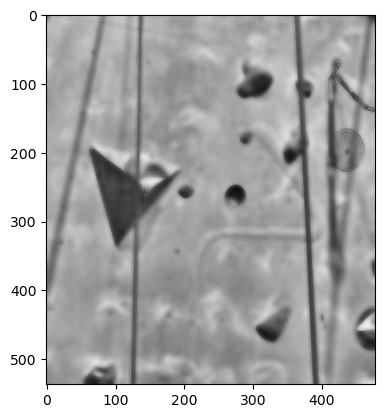

In [87]:
bilateral = cv2.bilateralFilter(clahe_img, 12, 150, 250)  
bilateral_rgb = cv2.cvtColor(bilateral, cv2.COLOR_BGR2RGB)  

plt.imshow(bilateral_rgb)

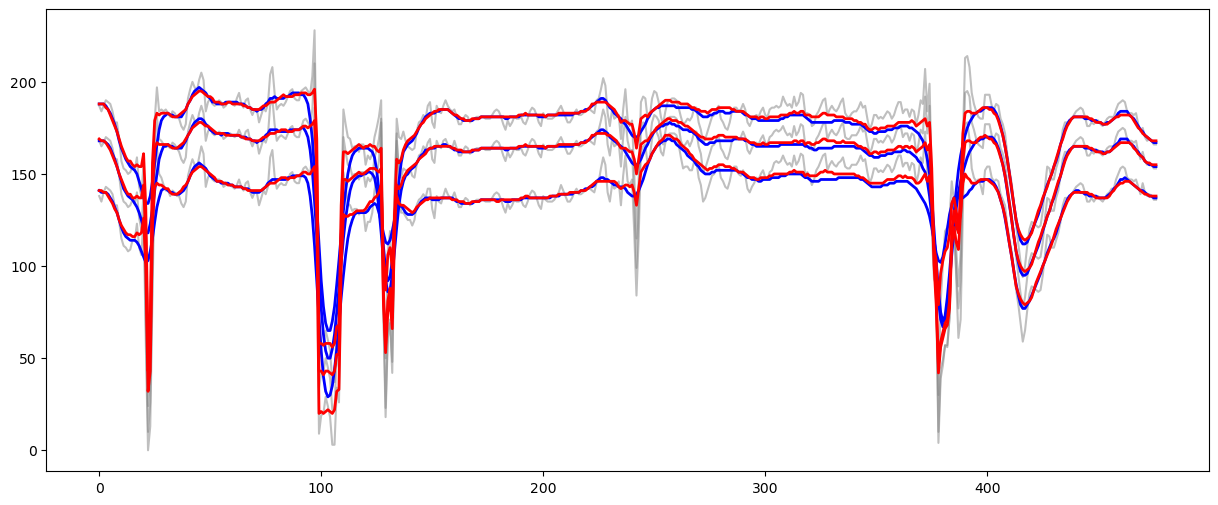

In [48]:
plt.figure(figsize=(15, 6))
row_idx = 330
# Plot Raw Data
plt.plot(image[row_idx, :], color='gray', alpha=0.5, label='Raw (Noisy)')

# Plot Gaussian
plt.plot(Gaussian_rgb[row_idx, :], color='blue', linewidth=2, label='Gaussian (Sloped Edge)')

plt.plot(bilateral_rgb[row_idx, :], color='red', linewidth=2, label='Gaussian (Sloped Edge)')


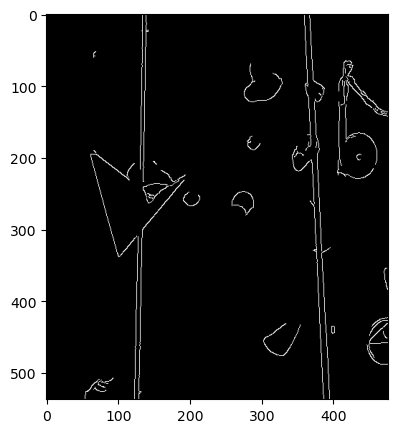

In [89]:
# Run Canny on your best Bilateral result
# Thresholds are guesses; use trackbars later to tune
edges_bilateral = cv2.Canny(bilateral_rgb, 100, 200)

plt.figure(figsize=(10,5))
plt.imshow(edges_bilateral, cmap='gray')
plt.show()

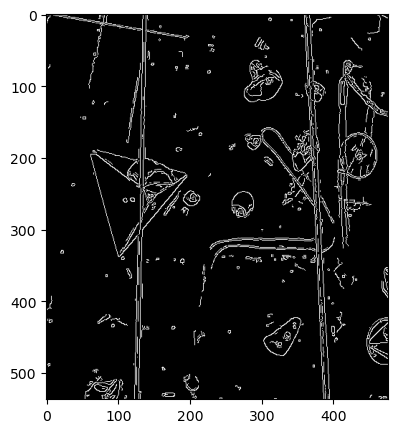

In [88]:
edges_crop = cv2.Canny(image, 100, 200)

plt.figure(figsize=(10,5))
plt.imshow(edges_crop, cmap='gray')
plt.show()

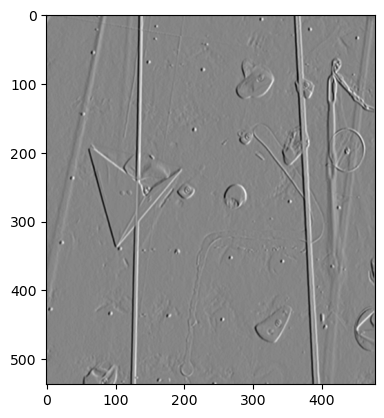

In [4]:
sobelx = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=1, dy=0, ksize=5) # Sobel Edge Detection on the X axis
sobely = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=0, dy=1, ksize=5) # Sobel Edge Detection on the Y axis
sobelxy = cv2.Sobel(src=gray_image, ddepth=cv2.CV_64F, dx=1, dy=1, ksize=5) # Combined X and Y Sobel Edge Detection

plt.imshow(sobelx, cmap='gray')


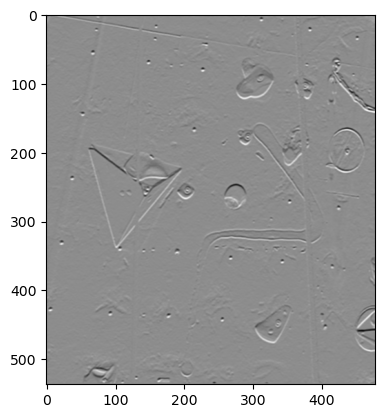

In [5]:
plt.imshow(sobely, cmap='gray')


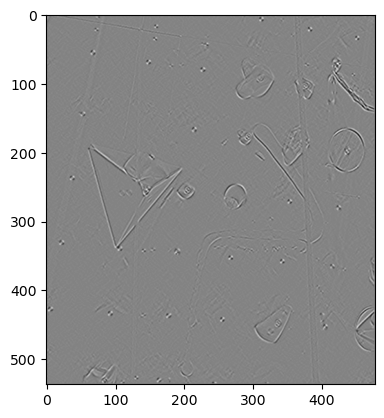

In [6]:
plt.imshow(sobelxy, cmap='gray')


In [ ]:
# Setup Blob Detector parameters for "Dark Dots"
params = cv2.SimpleBlobDetector_Params()

# Filter by Area (Size of the dot)
params.filterByArea = True
params.minArea = 10    # ~3x3 pixels
params.maxArea = 300   # ~17x17 pixels (Avoids big rocks)

# Filter by Circularity (roughly circular)
params.filterByCircularity = True
params.minCircularity = 0.6

# Filter by Convexity (optional, helps separate holes from weird shadows)
params.filterByConvexity = True
params.minConvexity = 0.87

# Filter by Inertia (how elongated it is)
params.filterByInertia = True
params.minInertiaRatio = 0.5

detector = cv2.SimpleBlobDetector_create(params)
keypoints = detector.detect(gray_image)  # Use Raw Grayscale!

In [ ]:

edges_inverted = cv2.bitwise_not(edges_canny)

# Calculate Distance to the nearest Zero (Black) pixel
dist_transform = cv2.distanceTransform(edges_inverted, cv2.DIST_L2, 5)

dist_transform = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)